## 🐻‍❄️ 투빅스 25&26기 6주차 — LLaVA 이미지 토큰 삽입 & ImageBind 관찰

#### ✅ 과제 목적
이번 주 발표에서 다룬 **MLLM 아키텍처(LLaVA)** 의 핵심을 직접 구현해 봅니다.

강력한 사전학습 Vision Encoder(CLIP)의 출력을 **projection 하나로 LLM 임베딩 공간에 정렬**하고,
그렇게 만든 **이미지 토큰을 텍스트 토큰 사이에 끼워 넣는 과정**을 손으로 재현합니다.

그 과정에서 발표의 핵심 부품이었던 **Cross-Attention** 이 "누가 누구를 참조하는가"에 따라
어떻게 달라지는지(Multimodal-CoT vs Latent Diffusion)도 직접 확인합니다.

Part A를 마치고 나면, 정렬(alignment)을 여러 모달로 확장한 **ImageBind** 의
"이미지 허브" 아이디어와 **emergent alignment** 를 사전학습 CLIP으로 관찰하는 심화 선택 파트가 이어집니다.

> - **Part A. LLaVA 이미지 토큰 삽입 (필수)** — CLIP 이미지 feature를 projection으로 LLM 차원에 맞추고,
>   이미지 토큰을 텍스트 토큰 사이에 삽입한 뒤, Cross-Attention의 방향을 직접 구현합니다.
> - **Part B. ImageBind 관찰 ** — 사전학습 CLIP으로 "이미지를 허브로" 정렬했을 때,
>   직접 학습하지 않은 모달 쌍도 가까워지는 emergent alignment를 측정합니다.

> 이 노트북은 아래 논문들을 따라갑니다.
> - LLaVA: Liu et al., [Visual Instruction Tuning](https://arxiv.org/abs/2304.08485) (NeurIPS 2023)
> - Multimodal-CoT: Zhang et al., [Multimodal Chain-of-Thought Reasoning in Language Models](https://arxiv.org/abs/2302.00923) (TMLR 2024)
> - Latent Diffusion: Rombach et al., [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752) (CVPR 2022)
> - ImageBind: Girdhar et al., [ImageBind: One Embedding Space To Bind Them All](https://arxiv.org/abs/2305.05665) (CVPR 2023)

> **데이터셋:** [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k) (Hugging Face `jxie/flickr8k`)
> - 이미지 하나당 caption 5개. Part A는 test에서 소수 이미지를, Part B는 test에서 200장을 사용합니다.

> **Part A에서 사용하는 encoder:**
> - 이미지: `openai/clip-vit-base-patch32` 의 vision encoder — 이미 CLIP으로 학습된 시각 인코더(발표의 LLaVA도 CLIP ViT를 씀)
> - 이 encoder는 froze 하고 feature만 뽑습니다. 우리가 다루는 건 그 위의 projection과 attention 계산뿐입니다.

> **Part B에서 사용하는 모델:** `openai/clip-vit-base-patch32` — 이미지·텍스트를 같은 공간에 두는 공개 체크포인트

#### ✅ 주의 사항
> - 코드 셀의 `# ===== TODO n =====` 블록을 순서대로 채우세요.
> - ⚠️ Hugging Face에서 데이터셋·모델을 내려받으므로 인터넷 연결(필요 시 토큰 로그인)이 되어 있어야 합니다.
> - `MY_SEED`(본인 학번 뒷 4자리)를 꼭 채우세요.
> - Part A 서술형은 총 3문항, Part B는 1문항입니다. **반드시 본인이 실행한 출력 숫자를 인용**해 답하세요.
> - ⚠️ 서술형은 정답 암기가 아니라 **논리**를 봅니다. AI에 통째로 묻지 말고, 발표 내용을 바탕으로 본인 언어로 쓰세요.

#### ✅ 제출물
> - Part A: 빈칸을 모두 채우고 전부 실행한 이 노트북 (출력 포함) — 필수
> - Part B: 빈칸을 모두 채우고 전부 실행한 이 노트북 (출력 포함) — 필수

### 🗺️ 실습 흐름

> **Part A. LLaVA 이미지 토큰 삽입 (필수)**
> 0. 환경 설정
> 1. 데이터 준비 & 확인
> 2. 고정된 CLIP Vision Encoder에서 이미지 feature 뽑기
> 3. Projection — 시각 feature를 LLM 임베딩 차원으로 정렬 (TODO)
> 4. 이미지 토큰을 텍스트 토큰 사이에 삽입 (TODO)
> 5. 📝 서술형 1 — 왜 이미지에만 projection이 필요한가
> 6. Cross-Attention 방향 이해 — MM-CoT vs Latent Diffusion (TODO)
> 7. 📝 서술형 2, 3

> **Part B. ImageBind 관찰**

> 8. 사전학습 CLIP으로 이미지 허브 정렬 재현 (TODO)
> 9. emergent alignment 측정 (TODO)
>10. 📝 서술형 4

### 📖 논문 대응표

| 노트북 | 논문 근거 |
|---|---|
| 3장 Projection | LLaVA §3 — 시각 feature `Z_v` 를 선형 사영 `W` 로 LLM 단어 임베딩 공간 `H_v` 로 변환 |
| 4장 이미지 토큰 삽입 | LLaVA Figure 1 — `H_v` 와 텍스트 토큰 `H_q` 를 이어붙여(concat) LLM 입력 시퀀스 구성 |
| 6장 Cross-Attention 방향 | Multimodal-CoT §4.2 (Q=텍스트) vs Latent Diffusion §3.3 (Q=이미지) |
| 8~9장 이미지 허브 / emergent | ImageBind §3 — 이미지와의 쌍만으로 정렬, 학습하지 않은 쌍도 정렬됨 |


# 🧭 Part A. LLaVA 이미지 토큰 삽입 (필수)

### ⚙️ 0. 환경 설정 — 라이브러리, 학생별 시드

In [ ]:
!pip uninstall -y transformers
!rm -rf /usr/local/lib/python3.13/dist-packages/transformers /usr/local/lib/python3.13/dist-packages/transformers-*.dist-info
!pip install -q --no-cache-dir "transformers==4.57.6"

import os; os.kill(os.getpid(), 9)   # 런타임 강제 재시작

Found existing installation: transformers 4.57.6
Uninstalling transformers-4.57.6:
  Successfully uninstalled transformers-4.57.6
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 112.1 MB/s eta 0:00:00


In [1]:
import transformers; print(transformers.__version__)

4.57.6


In [10]:
# 라이브러리 설치
# !pip -q install "transformers>=4.40,<5" "datasets>=2.19" pillow matplotlib


In [2]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import CLIPModel, CLIPProcessor

# ---- 실습 설정 ----
CLIP_CKPT = "openai/clip-vit-base-patch32"
CLIP_HIDDEN = 768     # CLIP vision encoder가 뽑는 시각 feature 차원 (Z_v)
LLM_HIDDEN  = 4096    # LLM(Vicuna 등)의 단어 임베딩 차원 (H_v가 맞춰야 할 목표)

# ===== TODO 0 =====
# 본인 학번 뒷 4자리를 넣으세요. (예: 202612345 -> 2345)
MY_SEED = 2041               # TODO: 학번 뒷 4자리
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
# ==================

TEST_POOL = 1000
SHOW_IDX = MY_SEED % TEST_POOL   # 학생마다 다른 확인 샘플

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device   :", device)
print("MY_SEED  :", MY_SEED)
print("확인 샘플:", SHOW_IDX)


device   : cuda
MY_SEED  : 2041
확인 샘플: 41


### 📦 1. 데이터 준비 & 확인
> Flickr8k에서 이미지 몇 장과 caption을 불러옵니다.

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


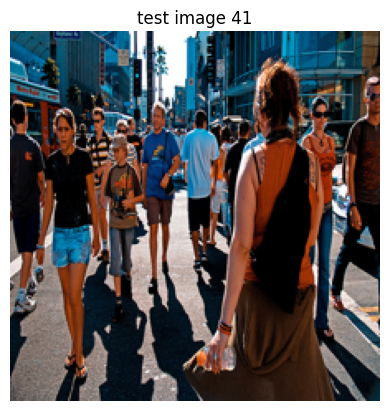

caption: A crowd of people walk down a busy sidewalk .


In [3]:
test_ds = load_dataset("jxie/flickr8k", split="test")

def img_of(i, size=(224, 224)):
    return test_ds[i]["image"].convert("RGB").resize(size)

# 확인용 샘플 이미지 + 첫 번째 caption
sample_img = img_of(SHOW_IDX)
sample_caption = test_ds[SHOW_IDX]["caption_0"]

plt.imshow(sample_img); plt.axis("off")
plt.title("test image %d" % SHOW_IDX)
plt.show()
print("caption:", sample_caption)


### 🧠 2. 고정된 CLIP Vision Encoder에서 이미지 feature 뽑기

> 📖 **논문 근거** — LLaVA는 CLIP ViT를 **고정(frozen)** 한 채 시각 feature만 뽑아 씁니다.

> 저희도 CLIP vision encoder를 얼려서 feature `Z_v` 만 얻습니다. (여기서는 768차원)


In [4]:
clip = CLIPModel.from_pretrained(CLIP_CKPT).to(device).eval()
proc = CLIPProcessor.from_pretrained(CLIP_CKPT)

@torch.no_grad()
def encode_image_patches(pil_img):
    """CLIP vision encoder로 이미지의 패치별 시각 feature를 뽑습니다.
    반환: [num_patches, 768]  (프로젝션 전 raw 시각 feature = Z_v)"""
    inputs = proc(images=pil_img, return_tensors="pt").to(device)
    vision_out = clip.vision_model(**inputs)          # frozen ViT
    # last_hidden_state: [1, num_patches+1, 768] (0번은 CLS 토큰)
    patches = vision_out.last_hidden_state[0, 1:, :]  # CLS 제외한 패치 토큰
    return patches.cpu()

Z_v = encode_image_patches(sample_img)
print("Z_v shape:", Z_v.shape, " <- (패치 개수, 768)  아직 LLM이 못 알아듣는 '비전 언어'")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Z_v shape: torch.Size([49, 768])  <- (패치 개수, 768)  아직 LLM이 못 알아듣는 '비전 언어'


### 🔧 3. Projection — 시각 feature를 LLM 임베딩 차원으로 정렬

> 📖 **논문 근거** — LLaVA §3. 학습 가능한 **선형 사영 W** 하나로
> 시각 feature `Z_v` (768차원)를 LLM 단어 임베딩 공간 `H_v` (4096차원)로 옮깁니다.
> Cross-Attention도 Q-Former도 아닌 **선형 층 하나** 라는 점이 핵심입니다.


In [5]:
class Projection(nn.Module):
    """LLaVA의 connector: 시각 feature -> LLM 임베딩 차원 (선형 사영 하나)"""
    def __init__(self, d_in=CLIP_HIDDEN, d_out=LLM_HIDDEN):
        super().__init__()
        # ===== TODO 1 =====
        # 힌트: d_in(768) 차원을 d_out(4096) 차원으로 보내는 nn.Linear 하나를 만드세요.
        self.proj = nn.Linear(d_in, d_out)   # TODO
        # ==================

    def forward(self, z_v):
        # ===== TODO 2 =====
        # 힌트: 위에서 만든 self.proj 에 z_v 를 통과시켜 H_v 를 반환하세요.
        H_v = self.proj(z_v)         # TODO
        # ==================
        return H_v

torch.manual_seed(MY_SEED)
projection = Projection()

H_v = projection(Z_v)
print("Z_v shape:", tuple(Z_v.shape), " ->  H_v shape:", tuple(H_v.shape))
assert H_v.shape[-1] == LLM_HIDDEN, "H_v의 마지막 차원이 LLM 임베딩 차원(4096)이어야 합니다!"
print("통과 ✅  이제 H_v 는 텍스트 토큰과 같은 차원 -> LLM 입력에 나란히 놓을 수 있습니다.")


Z_v shape: (49, 768)  ->  H_v shape: (49, 4096)
통과 ✅  이제 H_v 는 텍스트 토큰과 같은 차원 -> LLM 입력에 나란히 놓을 수 있습니다.


### 🧩 4. 이미지 토큰을 텍스트 토큰 사이에 삽입

> 📖 **논문 근거** — LLaVA Figure 1. `<image>` 자리에 이미지 토큰 `H_v` 를 끼워 넣어
> 텍스트 토큰 `H_q` 와 **하나의 입력 시퀀스**로 이어붙입니다(concat).

아래는 "USER: `<image>` What is in the photo? ASSISTANT:" 처럼
텍스트 사이에 이미지 자리(`<image>`)가 있는 상황을 단순화한 것입니다.


텍스트 토큰 임베딩은 예시로 무작위 생성합니다(실제로는 LLM의 임베딩 층에서 나옵니다).


In [6]:
# 텍스트 토큰 임베딩 (예시): "앞부분 3토큰" <image> "뒷부분 4토큰"
# 실제로는 LLM의 embed_tokens 층이 만들지만, 여기서는 무작위로 대체합니다.
torch.manual_seed(MY_SEED)
text_before = torch.randn(3, LLM_HIDDEN)   # <image> 앞 텍스트 토큰 3개
text_after  = torch.randn(4, LLM_HIDDEN)   # <image> 뒤 텍스트 토큰 4개

def build_input_sequence(text_before, image_tokens, text_after):
    """텍스트 토큰 사이의 <image> 자리에 이미지 토큰을 끼워 하나의 시퀀스로 합칩니다."""
    # ===== TODO 3 =====
    # 힌트: torch.cat([...], dim=0) 으로 (앞 텍스트) + (이미지 토큰) + (뒤 텍스트) 순서로 이어붙이세요.
    seq = torch.cat([text_before, image_tokens, text_after], dim=0)
   # TODO
    # ==================
    return seq

seq = build_input_sequence(text_before, H_v, text_after)
print("앞 텍스트:", tuple(text_before.shape))
print("이미지 토큰:", tuple(H_v.shape))
print("뒤 텍스트:", tuple(text_after.shape))
print("합쳐진 입력 시퀀스:", tuple(seq.shape))
expected = text_before.shape[0] + H_v.shape[0] + text_after.shape[0]
assert seq.shape == (expected, LLM_HIDDEN), "시퀀스 길이/차원이 맞지 않습니다!"
print("통과 ✅  이미지가 '가짜 단어 토큰'처럼 텍스트 사이에 들어갔습니다. 이제 LLM이 통째로 읽습니다.")


앞 텍스트: (3, 4096)
이미지 토큰: (49, 4096)
뒤 텍스트: (4, 4096)
합쳐진 입력 시퀀스: (56, 4096)
통과 ✅  이미지가 '가짜 단어 토큰'처럼 텍스트 사이에 들어갔습니다. 이제 LLM이 통째로 읽습니다.


### 📝 서술형 문제 1

위 3~4장의 결과(shape 출력)를 인용해서 답하세요.

1. 텍스트 토큰(`text_before`, `text_after`)은 projection을 거치지 않았는데도 이미지 토큰 `H_v` 와
   **그냥 이어붙일(concat) 수 있었습니다.** 두 종류 토큰의 shape를 인용하고, 이것이 가능했던 이유를 설명하세요.
2. 발표에서 "projection `W` 는 이미지에만 붙고 텍스트에는 붙지 않는다"고 했습니다.
   `Z_v`(768)와 `H_v`(4096), 그리고 텍스트 토큰(4096)의 차원을 근거로,
   **왜 이미지에만 W가 필요한지** 설명하세요. (LLM 입장에서 어느 쪽이 '모국어'인지 언급)

**✍️ 답변:**

1. 첫번째 텍스트는 (3, 4096), 그 다음 텍스트는 (4, 4096), 이미지 토큰 H_v는 (49, 4096)이고, 이어 붙인 시퀀스는 (56, 4096)이 됐다. dim=0 방향으로 붙일 때는 토큰 개수(첫 번째 차원)는 달라도 되고 마지막 차원만 같으면 된다. 세 텐서 모두 마지막 차원이 4096이라서 projection 없이도 이어 붙일 수 있었다. 텍스트 토큰이 처음부터 4096차원인 이유는 LLM의 임베딩 층에서 바로 나오는 값이기 때문이다.

2.CLIP에서 뽑은 Z_v는 (49, 768)이라 LLM이 받는 4096차원과 맞지 않는다. 차원만 문제라면 0을 채워 늘려도 된다. W가 필요한 진짜 이유는 Z_v가 CLIP이 이미지-텍스트 매칭을 위해 만든 공간의 값이라서, Vicuna가 학습한 단어 임베딩 공간과는 의미 체계가 다르다는 데 있다. LLM 입장에서 텍스트 토큰은 원래 읽던 모국어이고, Z_v는 처음 보는 비전 언어에 해당한다. 그래서 텍스트는 그대로 두고 이미지만 W를 거쳐 H_v(49, 4096)로 옮겨 LLM이 단어처럼 읽을 수 있게 만든다.

### 🔁 6. Cross-Attention 방향 — Multimodal-CoT vs Latent Diffusion

발표에서 같은 Cross-Attention이 두 모델에서 **방향(Q/K·V)이 반대**라고 배웠습니다.
- **Multimodal-CoT**: Q = 텍스트, K·V = 이미지  → 텍스트가 이미지를 참조 (이해·추론)
- **Latent Diffusion**: Q = 이미지, K·V = 텍스트 → 이미지가 텍스트를 참조 (생성)

아래 단순화한 cross-attention 함수를 완성하고, 두 방향을 직접 비교합니다.


In [7]:
def cross_attention(Q, K, V):
    """표준 (single-head) cross-attention.
    Q: [n_q, d], K: [n_k, d], V: [n_k, d] -> 출력 [n_q, d]"""
    d = Q.shape[-1]
    # ===== TODO 4 =====
    # 힌트 1: 점수 = Q @ K.T / sqrt(d)
    # 힌트 2: 가중치 = softmax(점수, dim=-1)
    # 힌트 3: 출력 = 가중치 @ V
    scores  = Q @ K.T / math.sqrt(d)   # TODO
    weights = F.softmax(scores, dim=-1)   # TODO
    out     = weights @ V   # TODO
    # ==================
    return out, weights

# 아주 단순한 예시: 텍스트 단어 2개, 이미지 패치 3개 (d=4)
text_tokens  = torch.tensor([[1.,0,1,0],
                             [0,1.,0,1]])          # "cat", "sky"
image_tokens = torch.tensor([[1.,0,1,0],           # 패치0: cat과 비슷
                             [0,1.,0,1],            # 패치1: sky와 비슷
                             [.5,.5,0,0]])          # 패치2: 중간

# (A) Multimodal-CoT 방향: 텍스트가 Query, 이미지가 K·V
outA, wA = cross_attention(Q=text_tokens, K=image_tokens, V=image_tokens)
# (B) Latent Diffusion 방향: 이미지가 Query, 텍스트가 K·V
outB, wB = cross_attention(Q=image_tokens, K=text_tokens, V=text_tokens)

print("[A] MM-CoT (Q=텍스트, K·V=이미지)  가중치 shape:", tuple(wA.shape), " <- 행=텍스트 단어, 열=이미지 패치")
print(wA.round(decimals=2))
print()
print("[B] LDM  (Q=이미지, K·V=텍스트)   가중치 shape:", tuple(wB.shape), " <- 행=이미지 패치, 열=텍스트 단어")
print(wB.round(decimals=2))


[A] MM-CoT (Q=텍스트, K·V=이미지)  가중치 shape: (2, 3)  <- 행=텍스트 단어, 열=이미지 패치
tensor([[0.5400, 0.2000, 0.2600],
        [0.2000, 0.5400, 0.2600]])

[B] LDM  (Q=이미지, K·V=텍스트)   가중치 shape: (3, 2)  <- 행=이미지 패치, 열=텍스트 단어
tensor([[0.7300, 0.2700],
        [0.2700, 0.7300],
        [0.5000, 0.5000]])


### 📝 서술형 문제 2

위 6장의 두 attention 가중치 행렬(`wA`, `wB`)의 **shape를 각각 인용**해서 답하세요.

1. `wA`(MM-CoT)와 `wB`(LDM)의 shape가 서로 다릅니다. 각 행렬에서 **행(row)이 무엇을 의미하고
   열(column)이 무엇을 의미하는지** 쓰고, 왜 shape가 달라지는지 설명하세요.
2. "누가 Query가 되는가"는 그 모델이 **무엇을 만들어내려 하는가(이해/추론 vs 생성)** 와 연결됩니다.
   MM-CoT과 LDM 각각에서 Query가 텍스트/이미지인 이유를, 각 모델의 목적과 연결해 설명하세요.

**✍️ 답변:**

1. wA는 (2, 3), wB는 (3, 2)로 나왔다. wA에서 행은 텍스트 단어(cat, sky)이고 열은 이미지 패치(0, 1, 2)다. 그래서 한 행은 그 단어가 각 패치를 얼마나 참고하는지를 나타낸다. 실제로 cat 행은 [0.54, 0.20, 0.26]으로, cat과 같은 벡터인 패치0에 가장 큰 가중치를 줬다. wB는 반대로 행이 이미지 패치, 열이 텍스트 단어다. 패치0은 [0.73, 0.27]로 cat 쪽을 주로 봤고, cat과 sky의 중간인 패치2는 [0.50, 0.50]으로 두 단어를 똑같이 봤다. attention 가중치는 (Query 개수, Key 개수) 모양으로 나온다. 그래서 Query를 텍스트(2개)로 두면 (2, 3), 이미지(3개)로 두면 (3, 2)가 되어 행과 열이 뒤바뀐다.

2. cross-attention의 출력은 Query 하나당 하나씩 나온다. outA는 2개이고 outB는 3개다. 즉 Query는 최종적으로 결과를 만들어야 하는 쪽이다. MM-CoT은 근거와 정답이라는 텍스트를 만들어야 하므로, 텍스트 토큰이 Query가 되어 이미지 패치에서 필요한 시각 정보를 끌어온다. 발표의 자석 예시처럼 텍스트가 이미지를 확인하지 않으면 근거가 틀어지기 때문에, 텍스트가 이미지를 찾아보는 방향이어야 한다. 반대로 LDM은 이미지(잠재 z)를 만들어야 하므로, z의 각 위치가 Query가 되어 이 자리에 무엇을 그려야 하는지를 텍스트 조건에서 찾는다. 같은 계산이지만 결과물이 텍스트인지 이미지인지에 따라 Query가 정해지는 것이다!


### 📝 서술형 문제 3

발표에서 "Cross-Attention은 멀티모달 생성 모델의 **조종간**" 이라고 했습니다.

**Latent Diffusion에서 Cross-Attention으로 텍스트 조건을 넣지 않는다면**, "고양이를 그려줘"라는 요청에
모델은 무엇을 생성하게 될까요? 그리고 그 이유를 6장의 (B) 방향(이미지가 텍스트를 참조)과 연결해 설명하세요.

**✍️ 답변:** 텍스트 조건을 cross-attention으로 넣지 않으면 모델은 '고양이를 그려줘' 문장을 전혀 볼 수 없다. 그래서 학습 데이터에서 본 이미지들과 비슷한 그럴듯한 이미지를 하나 만들 뿐이고, 그게 고양이일지 풍경일지는 알 수 없다. 사실상 조건 없는 생성이 된다.
원래는 이미지 위치가 Query로 텍스트 단어를 참조해서 wB 같은 가중치를 만든다. 예를 들어 패치0이 cat에 0.73을 주는 식으로 텍스트 정보를 자기 위치로 가져오는 것이다. cross-attention이 없으면 이 wB 자체가 계산되지 않으니 텍스트 정보가 이미지 쪽으로 넘어갈 길이 없다. 또 세션에서 diffusion은 노이즈를 여러 스텝에 걸쳐 지우기 때문에 조건을 매 스텝 참조해야 뒤쪽에서 벗어나지 않는다고 했다. 한 번만 줘도 흔들릴 수 있는데 아예 주지 않으면 처음부터 방향이 없다.


# 🔍 Part B. ImageBind 관찰

Part A에서 만든 것은 이미지-텍스트 **두 모달**의 연결이었습니다.
ImageBind는 이 아이디어를 여러 모달로 확장하되, **모든 쌍을 학습하지 않고 "이미지와의 쌍"만** 학습합니다.
그 결과 **직접 학습하지 않은 모달 쌍도 가까워지는** emergent alignment가 나타납니다.

여기서는 오디오·깊이 센서 대신, 우리가 접근 가능한 **사전학습 CLIP의 이미지·텍스트 공간**을 이용해
"이미지를 허브로 삼으면 왜 학습 안 한 쌍도 가까워지는가"를 숫자로 확인합니다.


### 📦 8. 사전학습 CLIP으로 이미지 허브 정렬 재현

> 📖 **논문 근거** — ImageBind §3. 각 모달을 **이미지와** 정렬하면, 이미지가 공통 기준점(허브)이 됩니다.

시나리오: 같은 대상('개')에 대한 서로 다른 두 텍스트 표현 A, B가 있다고 합시다.
둘 다 **개 이미지와 각각 정렬**되어 있다면(=이미지 허브), A와 B를 직접 비교한 적이 없어도 가까울까요?


In [8]:
@torch.no_grad()
def clip_image_embed(pil_img):
    inputs = proc(images=pil_img, return_tensors="pt").to(device)
    e = clip.get_image_features(**inputs)[0]
    return F.normalize(e, dim=-1).cpu()

@torch.no_grad()
def clip_text_embed(text):
    inputs = proc(text=[text], return_tensors="pt", padding=True).to(device)
    e = clip.get_text_features(**inputs)[0]
    return F.normalize(e, dim=-1).cpu()

def cos(a, b):
    return float(torch.dot(a, b))

# 개가 있는 이미지 하나를 test set에서 찾기: caption에 'dog'가 있는 첫 이미지
dog_idx = None
for i in range(len(test_ds)):
    if "dog" in test_ds[i]["caption_0"].lower():
        dog_idx = i; break
print("개 이미지 index:", dog_idx, "| caption:", test_ds[dog_idx]["caption_0"])

img_dog   = clip_image_embed(test_ds[dog_idx]["image"].convert("RGB"))   # 허브(이미지)
text_A    = clip_text_embed("a photo of a dog")        # 표현 A
text_B    = clip_text_embed("a puppy playing outside") # 표현 B (개를 다르게 표현)
text_far  = clip_text_embed("a red sports car")        # 무관한 표현

print("\n[이미지 허브와의 정렬]")
print("img_dog ↔ text_A(dog)   :", round(cos(img_dog, text_A), 3))
print("img_dog ↔ text_B(puppy) :", round(cos(img_dog, text_B), 3))
print("img_dog ↔ text_far(car) :", round(cos(img_dog, text_far), 3))


개 이미지 index: 0 | caption: The dogs are in the snow in front of a fence .

[이미지 허브와의 정렬]
img_dog ↔ text_A(dog)   : 0.255
img_dog ↔ text_B(puppy) : 0.253
img_dog ↔ text_far(car) : 0.17


### 📊 9. emergent alignment 측정

이제 **이미지를 거치지 않고 텍스트끼리 직접** 비교합니다.
A와 B는 서로 학습·비교된 적 없지만, 둘 다 개 이미지(허브)와 가깝다면 서로도 가까울 것으로 기대됩니다.


In [9]:
# ===== TODO 5 =====
# 힌트: 위에서 만든 cos() 함수로 텍스트-텍스트 유사도를 직접 구하세요.
sim_A_B   = cos(text_A, text_B)   # TODO: text_A 와 text_B 의 코사인 유사도
sim_A_far = cos(text_A, text_far)   # TODO: text_A 와 text_far 의 코사인 유사도
# ==================

print("text_A(dog) ↔ text_B(puppy) :", round(sim_A_B, 3), " <- 개끼리(허브 공유)")
print("text_A(dog) ↔ text_far(car) :", round(sim_A_far, 3), " <- 무관")
print()
if sim_A_B > sim_A_far:
    print("✅ 이미지 허브를 공유한 표현끼리 더 가깝다 -> emergent alignment 의 직관")


text_A(dog) ↔ text_B(puppy) : 0.836  <- 개끼리(허브 공유)
text_A(dog) ↔ text_far(car) : 0.72  <- 무관

✅ 이미지 허브를 공유한 표현끼리 더 가깝다 -> emergent alignment 의 직관


### 📝 서술형 문제 4

8~9장의 숫자를 **모두 인용**해서 답하세요.

1. `img_dog ↔ text_A`, `img_dog ↔ text_B` (8장)와 `text_A ↔ text_B` (9장)를 함께 인용해서,
   "두 표현이 각각 이미지(허브)와 가까웠다"는 사실과 "두 표현이 서로 가까웠다"는 사실을 연결해 설명하세요.
2. 발표의 ImageBind는 (이미지, 오디오)와 (이미지, 텍스트)만 학습해도 (오디오, 텍스트)가 정렬됐습니다.
   이 노트북 실험이 그 현상과 **어떻게 닮았고 어디가 다른지** 한 가지씩 쓰세요.
   (힌트: 우리는 진짜 오디오 대신 무엇으로 대체했나?)

**✍️ 답변:**

1. 사용한 이미지는 0번 사진이다. 이 이미지와의 유사도를 보면 img_dog ↔ text_A(dog)는 0.255, img_dog ↔ text_B(puppy)는 0.253으로 거의 같았고, 둘 다 img_dog ↔ text_far(car)의 0.17보다 높았다. 즉 두 표현 모두 개 이미지라는 같은 기준점 근처에 있다. 9장에서 이미지를 거치지 않고 텍스트끼리 비교하자 text_A ↔ text_B는 0.836으로 text_A ↔ text_far의 0.72보다 높았다. A와 B를 직접 비교한 적은 없지만, 둘 다 같은 이미지 쪽에 비슷한 거리로 모여 있으니 서로도 가깝게 나온 것이다. 이미지를 허브로 두면 허브를 공유한 표현끼리 따로 학습하지 않아도 정렬된다는 ImageBind의 직관을 숫자로 확인할 수 있었다.
이미지-텍스트 유사도는 가장 높아도 0.255인데, 텍스트끼리는 관계없는 car 문장과도 0.72가 나왔다. 같은 공간 안에서도 이미지 임베딩과 텍스트 임베딩이 서로 다른 영역에 따로 모여 있다는 뜻으로 보인다. 지난주 Mind the Gap에서 본 modality gap이 여기서도 나타난 것 같다. 그래서 절대값보다는 같은 기준 안에서 어느 쪽이 더 높은지를 비교하는 게 의미가 있다고 생각한다.

2. 닮은 점은 A와 B를 직접 짝지어 학습한 적이 없는데도, 둘 다 이미지와 정렬된 공간에 있다는 이유로 서로 가까워졌다는 것이다. ImageBind에서 (오디오, 텍스트)를 학습하지 않았는데도 정렬된 것과 같은 구조다.
다른 점은 진짜 오디오 대신 또 다른 텍스트 문장으로 대체했다는 것이다. A와 B는 같은 CLIP 텍스트 인코더를 거치고, CLIP이 학습할 때 dog나 puppy가 들어간 비슷한 캡션도 많이 봤을 것이다. 그러니 이미지 허브가 없어도 원래 가까웠을 가능성이 있다. 실제로 무관한 car 문장과도 0.72가 나온 걸 보면 텍스트끼리는 기본적으로 꽤 가깝게 모여 있다. 이 실험은 아무것도 학습하지 않고, 이미 학습된 CLIP을 관찰만 했다는 점도 다르다.


#### 📚 참고 자료

**Part A**
- LLaVA: [Visual Instruction Tuning](https://arxiv.org/abs/2304.08485) (Liu et al., 2023) · [코드](https://github.com/haotian-liu/LLaVA)
- Multimodal-CoT: [Multimodal Chain-of-Thought Reasoning in Language Models](https://arxiv.org/abs/2302.00923) (Zhang et al., 2024)
- Latent Diffusion: [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752) (Rombach et al., 2022)

**Part B**
- ImageBind: [One Embedding Space To Bind Them All](https://arxiv.org/abs/2305.05665) (Girdhar et al., 2023) · [코드](https://github.com/facebookresearch/ImageBind)

**더 읽어보기**
- Show-o: [One Single Transformer to Unify Multimodal Understanding and Generation](https://arxiv.org/abs/2408.12528) (ICLR 2025)
